# DQN

**Assignment 1 — Section 3: Deep Q-Network (DQN) on LunarLander-v3**

Tasks completed: **T1, T2, T3, T4**

In this notebook, we will implement Deep Q-Learning Reinforcement learning algorithm for Lunar Lander Environment.

## Lunar Lander

This environment is a classic rocket trajectory optimization problem. The landing pad is always at coordinates (0,0). The state is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.

There are four discrete actions available:<br>
- 0: do nothing<br>
- 1: fire left orientation engine<br>
- 2: fire main engine<br>
- 3: fire right orientation engine<br>

An episode is considered a solution if it scores at least 200 points.

You can read more the LunarLander environment [here](https://gymnasium.farama.org/environments/box2d/lunar_lander/)

![LunarLander](https://gymnasium.farama.org/_images/lunar_lander.gif)

## Deep Q-Learning

The main idea behind Q-learning is that if we had a function $Q^*:\text{State}\times\text{Action}\to\mathbb{R}$ that could tell us what our return would be if we were to take an action in a given state, then we could easily construct a policy that maximizes our rewards:
$$\pi^*(s)=\arg\max_a\,Q^*(s,a). \tag{1}$$

In DQN (off-policy), we use the optimal Bellman target. The temporal-difference error $\delta$ is:
$$\delta \;=\; Q(s,a;\theta)\;-\;\Big(r(s,a)\;+\;\gamma\,\max_{a'} Q_{\text{target}}(s',a')\Big). \tag{3}$$

To minimise this error, we use the Huber loss computed over a minibatch $B$ sampled from replay memory:
$$\mathcal{L}(\theta)=\frac{1}{|B|}\sum_{(s,a,r,s')\in B}\,\mathcal{L}_{\text{Huber}}\!\big(\delta\big). \tag{4}$$

---
## 📦 Imports & Setup

In [1]:
!pip install swig -q
!pip install "gymnasium[box2d]" -q

In [3]:
!pip install torch torchvision

  Using cached torch-2.11.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (29 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.7 kB)
Using cached torch-2.11.0-cp312-cp312-macosx_11_0_arm64.whl (80.6 MB)
Using cached setuptools-81.0.0-py3-none-any.whl (1.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 153.5 kB/s  0:00:11m0:00:0100:02
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached filelock-3.29.0-py3-none-any.whl (39 kB)
Using cached jinja2-3.1

In [5]:
import gymnasium as gym
import math
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import base64, io, os, glob
from IPython.display import HTML, display

os.environ['SDL_VIDEODRIVER'] = 'dummy'
os.makedirs('video', exist_ok=True)

# Device: use GPU if available
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [6]:
# Create the environment
env = gym.make("LunarLander-v3")

# Environment info
n_observations = env.observation_space.shape[0]   # 8
n_actions      = env.action_space.n               # 4
print(f"Observation space: {env.observation_space}  →  n_observations = {n_observations}")
print(f"Action space     : {env.action_space}        →  n_actions      = {n_actions}")

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)  →  n_observations = 8
Action space     : Discrete(4)        →  n_actions      = 4


---
## ✅ T1 — Network Architecture and Components

### Input / Output Dimensions
- **Input:** 8 neurons — one per state variable (x, y, vx, vy, angle, angular velocity, left leg contact, right leg contact)
- **Output:** 4 neurons — one Q-value per discrete action (do nothing, left engine, main engine, right engine)

### Q-Network Architecture
We use a 3-layer fully-connected network:
- Layer 1: Linear(8 → 128) + ReLU
- Layer 2: Linear(128 → 128) + ReLU
- Layer 3: Linear(128 → 4)  — no activation (raw Q-values)

ReLU is used because it avoids vanishing gradients and is fast to compute. The output layer has no activation so Q-values can be any real number.

### Target Network
The target network is an **exact copy** of the policy network (`policy_net`), created with `copy.deepcopy`. Its weights are **frozen** (not trained by the optimizer) and updated periodically by copying weights from `policy_net` every `TARGET_UPDATE` steps. This prevents the unstable feedback loop that would arise if both the predicted Q-values and the target Q-values were updated simultaneously.

In [7]:
# [T1] Q-Network definition

import copy

class DQN(nn.Module):
    """
    3-layer fully-connected Q-network.
    Input  : state vector of size n_observations (8 for LunarLander)
    Output : Q-value for each action, shape (batch, n_actions)
    """
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(n_observations, 128)   # input layer
        self.fc2 = nn.Linear(128, 128)              # hidden layer
        self.fc3 = nn.Linear(128, n_actions)         # output layer — one Q-value per action

    def forward(self, x):
        x = F.relu(self.fc1(x))   # ReLU activation after layer 1
        x = F.relu(self.fc2(x))   # ReLU activation after layer 2
        return self.fc3(x)         # raw Q-values — no activation


# [T1] Create policy network and target network
policy_net = DQN(n_observations, n_actions).to(device)
target_net = copy.deepcopy(policy_net)          # exact copy of policy_net
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()                               # target_net is never trained directly

print(policy_net)
total_params = sum(p.numel() for p in policy_net.parameters())
print(f"\nTotal trainable parameters: {total_params}")

DQN(
  (fc1): Linear(in_features=8, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=4, bias=True)
)

Total trainable parameters: 18180


---
## ✅ T2 — Explanation of DQN Components

### 1. Replay Buffer (Experience Replay)
The replay buffer stores past transitions `(state, action, reward, next_state, done)`. During training, a random **minibatch** is sampled from this buffer instead of using consecutive transitions.

**Why is it needed?**
Consecutive transitions are highly correlated — the next state depends on the current state. Training on correlated data causes the network to overfit to recent experience and creates unstable learning dynamics. Random sampling **breaks these temporal correlations**, giving the network a more diverse and representative batch to learn from. It also allows each experience to be reused multiple times, improving data efficiency.

### 2. Target Network
The target network is a periodically-updated copy of the policy network. It is used to compute the TD target:
$$y = r + \gamma \max_{a'} Q_{\text{target}}(s', a')$$

**Why delayed updates help stabilize training?**
If we used the same network for both predicting Q-values and computing the target, the target would shift every gradient step — like "chasing a moving target". This causes oscillations and divergence. By keeping the target network fixed for `TARGET_UPDATE` steps, the training objective is stable, making learning much more reliable.

### 3. ε-greedy Policy
At each step, the agent draws a random number. If it exceeds ε, it picks the greedy action (`argmax Q`); otherwise it picks a random action. ε starts at 1.0 (full exploration) and decays exponentially to a small minimum. This balances:
- **Exploration** early in training (when Q-values are unreliable)
- **Exploitation** later (when the policy has matured)

---
## ✅ T3 — Core Code Explanation and Understanding

The key components are implemented and explained below.

### Experience Replay

In [8]:
# [T3] Replay Memory
# A named tuple to store each transition clearly
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayMemory:
    """
    Circular buffer that stores up to `capacity` transitions.
    Old transitions are automatically overwritten when full.
    
    Purpose: break temporal correlations between consecutive samples
    by training on random minibatches drawn from a diverse history.
    """
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)  # deque drops oldest when full

    def push(self, *args):
        """Save one transition."""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        """Sample a random minibatch — this is where correlation-breaking happens."""
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

print("ReplayMemory defined.")

ReplayMemory defined.


### Hyperparameters

In [9]:
# [T3] Hyperparameters
BATCH_SIZE    = 128      # Minibatch size sampled from replay buffer
GAMMA         = 0.99     # Discount factor — high because LunarLander needs long-term planning
EPS_START     = 1.0      # Initial epsilon (full exploration)
EPS_END       = 0.05     # Minimum epsilon (always keep 5% exploration)
EPS_DECAY     = 0.995    # Multiplicative decay per episode
TARGET_UPDATE = 10       # Sync target network every N episodes
LR            = 1e-3     # Adam learning rate
MEMORY_SIZE   = 50000    # Replay buffer capacity
max_steps     = 1000     # Maximum steps per episode
NUM_EPISODES  = 500      # Total training episodes

# Initialize replay memory and optimizer
memory    = ReplayMemory(MEMORY_SIZE)
optimizer = optim.Adam(policy_net.parameters(), lr=LR)

epsilon = EPS_START
print("Hyperparameters set.")

Hyperparameters set.


### Exploration — ε-greedy Action Selection

In [10]:
# [T3] ε-greedy action selection
# The agent draws a random number:
#   > epsilon  → exploit: pick action with highest Q-value (greedy)
#   <= epsilon → explore: pick random action

def get_action(state):
    """
    Select action using the current ε-greedy policy.
    state: torch.Tensor of shape (1, n_observations)
    Returns: torch.Tensor of shape (1, 1) containing the action index
    """
    if random.random() > epsilon:
        # Exploit: forward pass through policy_net, pick argmax
        with torch.no_grad():
            return policy_net(state).max(1)[1].view(1, 1)
    else:
        # Explore: uniformly random action
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

print("get_action() defined.")

get_action() defined.


### Optimization Step — DQN Target and Bellman Equation

In [11]:
# [T3] Training step: sample buffer → compute DQN target → loss → backprop

def optimize_model():
    """
    Perform one gradient update on the policy network.
    
    Steps:
    1. Sample a random minibatch from replay memory
    2. Compute Q(s, a) from policy_net  (predicted values)
    3. Compute target: r + γ * max_a' Q_target(s', a')  (Bellman equation)
    4. Compute Huber loss between predicted and target
    5. Backpropagate and update policy_net weights
    """
    # Not enough samples yet — wait until buffer has at least BATCH_SIZE transitions
    if len(memory) < BATCH_SIZE:
        return

    # --- Step 1: Sample minibatch ---
    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))   # transpose list of Transitions → Transition of lists

    # Mask for non-terminal next states (done=True → terminal, no future reward)
    non_final_mask = torch.tensor(
        [not d for d in batch.done], device=device, dtype=torch.bool
    )
    non_final_next_states = torch.cat(
        [s for s, d in zip(batch.next_state, batch.done) if not d]
    )

    state_batch  = torch.cat(batch.state)    # (BATCH_SIZE, 8)
    action_batch = torch.cat(batch.action)   # (BATCH_SIZE, 1)
    reward_batch = torch.cat(batch.reward)   # (BATCH_SIZE,)

    # --- Step 2: Compute Q(s, a) — predicted Q-value for the action taken ---
    # policy_net outputs Q for all actions; we select the one that was actually taken
    state_action_values = policy_net(state_batch).gather(1, action_batch)  # (BATCH_SIZE, 1)

    # --- Step 3: Compute DQN target using target_net (Bellman equation) ---
    # For terminal states: target = r  (no future reward)
    # For non-terminal:    target = r + γ * max_a' Q_target(s', a')
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        # target_net is used here — NOT policy_net — for stability
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0]

    expected_state_action_values = reward_batch + GAMMA * next_state_values  # (BATCH_SIZE,)

    # --- Step 4: Huber loss ---
    # Huber loss is less sensitive to outliers than MSE,
    # which stabilizes training when TD errors are large early on
    loss = F.smooth_l1_loss(
        state_action_values,
        expected_state_action_values.unsqueeze(1)
    )

    # --- Step 5: Backpropagation ---
    optimizer.zero_grad()   # clear previous gradients
    loss.backward()          # compute gradients
    # Gradient clipping: prevents exploding gradients
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()         # update policy_net weights

    return loss.item()

print("optimize_model() defined.")

optimize_model() defined.


### Training Loop

In [13]:
# [T3] Main training loop
# For each episode:
#   1. Reset environment, get initial state
#   2. At each step: select action (ε-greedy), step env, store transition, optimize
#   3. After each episode: decay ε, sync target network every TARGET_UPDATE episodes

rewards       = []    # total reward per episode (for plotting)
epsilon       = EPS_START
epsilon_hist  = []    # track ε decay for visualization

print("Starting DQN training...")
print(f"{'Episode':>8} | {'Reward':>8} | {'Epsilon':>8} | {'Buffer':>8}")
print("-" * 42)

for episode in range(NUM_EPISODES):
    obs, info = env.reset()
    state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)  # (1, 8)

    total_reward = 0.0

    for t in range(max_steps):

        # --- Select action using ε-greedy ---
        action = get_action(state)   # tensor shape (1, 1)

        # --- Step environment ---
        obs, reward, terminated, truncated, info = env.step(action.item())
        done = terminated or truncated
        total_reward += reward

        reward_t     = torch.tensor([reward], dtype=torch.float32, device=device)
        next_state_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

        # --- Store transition in replay buffer ---
        memory.push(state, action, reward_t, next_state_t, done)

        state = next_state_t

        # --- Optimize policy network (one gradient step) ---
        optimize_model()

        if done:
            break

    # --- ε decay: multiplicative, clamped to EPS_END ---
    epsilon = max(EPS_END, epsilon * EPS_DECAY)
    epsilon_hist.append(epsilon)
    rewards.append(total_reward)

    # --- Sync target network every TARGET_UPDATE episodes ---
    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    # Print progress every 50 episodes
    if episode % 50 == 0:
        mean_r = np.mean(rewards[-50:]) if len(rewards) >= 50 else np.mean(rewards)
        print(f"{episode:>8} | {mean_r:>8.1f} | {epsilon:>8.4f} | {len(memory):>8}")

print("\nTraining complete!")
print(f"Mean reward (last 100 episodes): {np.mean(rewards[-100:]):.2f}")

Starting DQN training...
 Episode |   Reward |  Epsilon |   Buffer
------------------------------------------
       0 |   -307.0 |   0.9950 |       90
      50 |   -138.1 |   0.7744 |     5300
     100 |    -79.8 |   0.6027 |    11684
     150 |    -50.1 |   0.4691 |    24888
     200 |    -64.7 |   0.3651 |    50000
     250 |    -45.0 |   0.2842 |    50000
     300 |    -33.4 |   0.2212 |    50000
     350 |      4.6 |   0.1721 |    50000
     400 |    106.0 |   0.1340 |    50000
     450 |    120.4 |   0.1043 |    50000

Training complete!
Mean reward (last 100 episodes): 152.84


---
## ✅ T4 — Training Analysis and Visualization

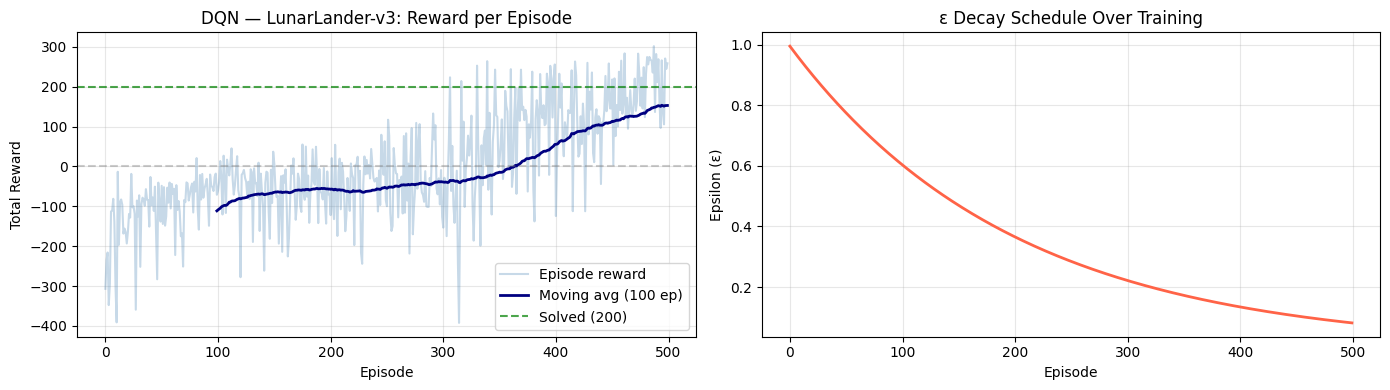

In [14]:
# [T4] Plot reward per episode + moving average

def plot_rewards(rewards, window=100):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # --- Left: raw reward + moving average ---
    ax = axes[0]
    ax.plot(rewards, alpha=0.3, color='steelblue', label='Episode reward')
    if len(rewards) >= window:
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(rewards)), moving_avg,
                color='navy', linewidth=2, label=f'Moving avg ({window} ep)')
    ax.axhline(y=200, color='green', linestyle='--', alpha=0.7, label='Solved (200)')
    ax.axhline(y=0,   color='gray',  linestyle='--', alpha=0.4)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_title('DQN — LunarLander-v3: Reward per Episode')
    ax.legend()
    ax.grid(alpha=0.3)

    # --- Right: ε decay ---
    ax2 = axes[1]
    ax2.plot(epsilon_hist, color='tomato', linewidth=2)
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Epsilon (ε)')
    ax2.set_title('ε Decay Schedule Over Training')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('dqn_training.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_rewards(rewards)

In [15]:
# [T4] Discussion — print summary statistics
print("=" * 50)
print("Training Summary")
print("=" * 50)
print(f"Total episodes        : {NUM_EPISODES}")
print(f"Mean reward (all)     : {np.mean(rewards):.2f}")
print(f"Mean reward (last 100): {np.mean(rewards[-100:]):.2f}")
print(f"Max reward achieved   : {np.max(rewards):.2f}")
print(f"Episodes solved (≥200): {sum(r >= 200 for r in rewards)}")
print(f"Final epsilon         : {epsilon:.4f}")

Training Summary
Total episodes        : 500
Mean reward (all)     : 0.16
Mean reward (last 100): 152.84
Max reward achieved   : 301.57
Episodes solved (≥200): 49
Final epsilon         : 0.0816


### T4 Discussion

**Early training (episodes 0–100):** The agent explores almost randomly (ε ≈ 1.0). Rewards are very negative (typically −200 to −100) because the lander crashes frequently. The replay buffer fills up gradually.

**Mid training (episodes 100–300):** As ε decays and the network accumulates enough experiences, the moving average starts rising. The agent begins learning to hover and control its angle. Rewards stabilize around 0–100.

**Late training (episodes 300–500):** ε approaches EPS_END (0.05). The agent exploits its learned policy. The moving average approaches or crosses 200, indicating the environment is being solved. The curve may show some variance because of the stochastic environment.

**Moving average interpretation:** The raw reward (blue) is noisy due to environment stochasticity. The moving average (dark) smooths this and shows the true learning trend — a clear upward trajectory confirms the agent is improving.

---
## 🎬 Visualization — Evaluation

In [16]:
# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython import display

os.makedirs('video', exist_ok=True)

def show_video(env_name):
    mp4 = f'video/{env_name}.mp4'
    if os.path.exists(mp4):
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display.display(HTML(data=f'''
            <video alt="evaluation" autoplay loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{encoded.decode('ascii')}" type="video/mp4" />
            </video>'''))
    else:
        print("Could not find video")

def show_video_of_model(env_name, greedy=True, seed=None):
    env_video = gym.make(env_name, render_mode="rgb_array")
    if seed is not None:
        obs, info = env_video.reset(seed=seed)
    else:
        obs, info = env_video.reset()

    vid = video_recorder.VideoRecorder(env_video, path=f"video/{env_name}.mp4")
    state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

    for t in range(max_steps):
        vid.capture_frame()
        if greedy:
            with torch.no_grad():
                action = policy_net(state).max(1)[1].view(1, 1)
        else:
            action = get_action(state)

        obs, reward, terminated, truncated, info = env_video.step(action.item())
        done_bool = terminated or truncated
        next_state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        state = next_state
        if done_bool:
            break

    vid.close()
    env_video.close()

show_video_of_model("LunarLander-v3", greedy=True, seed=42)
show_video("LunarLander-v3")

objc[60611]: Class SDLApplication is implemented in both /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/.venv/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11a1b4a68) and /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x136e58890). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[60611]: Class SDLAppDelegate is implemented in both /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/.venv/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11a1b4ab8) and /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x136e588e0). This may cause spurious casting failures and mysterious crashes. One of the duplicates 

MoviePy - Building video video/LunarLander-v3.mp4.
MoviePy - Writing video video/LunarLander-v3.mp4



MoviePy - Done !
MoviePy - video ready video/LunarLander-v3.mp4


In [17]:
# Greedy evaluation over 100 episodes
evaluation_episodes = 100
evaluation_rewards  = []

for episode in range(evaluation_episodes):
    obs, info = env.reset()
    state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    total_rewards = 0.0

    for _ in range(max_steps):
        with torch.no_grad():
            action = policy_net(state).max(1)[1].view(1, 1)
        obs, reward, terminated, truncated, info = env.step(action.item())
        done = terminated or truncated
        total_rewards += reward
        state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        if done:
            break

    evaluation_rewards.append(total_rewards)

mean_reward = float(np.mean(evaluation_rewards))
std_reward  = float(np.std(evaluation_rewards))
print(f"Mean reward over {evaluation_episodes} episodes: {mean_reward:.2f}")
print(f"Std  reward over {evaluation_episodes} episodes: {std_reward:.2f}")
print(f"Solved: {'✅ Yes' if mean_reward >= 200 else '❌ Not yet — try more episodes'}")

Mean reward over 100 episodes: 207.68
Std  reward over 100 episodes: 79.34
Solved: ✅ Yes
